Regression related problem pipeline এখানে মূলত regression related একটি CSV এর problem এর full pipeline এর কোড করা হয়েছে, যেখানে বিভিন্ন model apply করা হয়েছে এবং সবকিছু দেখা হয়েছে।

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression,ElasticNet,SGDRegressor,Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor,StackingRegressor

import warnings
warnings.filterwarnings('ignore')


In [40]:
train_df=pd.read_csv("dataset.csv")
test_df = pd.read_csv("test.csv")
# keep a copy of the test IDs for submission
test_ids = test_df['PID'].copy()
test_df=test_df.drop(columns=['PID'])

In [41]:
test_df.head(3)

,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,1358,70,RM,NaN,5100,Pave,Grvl,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2008,WD,Normal
1,2368,160,RM,21.0,1890,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal
2,2823,60,RL,62.0,7162,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal


In [42]:
train_df.head(3)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1323,902405070,70,RM,60.0,10800,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,184000
1,2476,531376030,60,RL,65.0,7800,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,184000
2,2091,906201022,20,RL,114.0,10357,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,179900


In [43]:
test_df.head(5)

,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,1358,70,RM,NaN,5100,Pave,Grvl,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2008,WD,Normal
1,2368,160,RM,21.0,1890,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal
2,2823,60,RL,62.0,7162,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal
3,2127,20,RL,60.0,8070,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
4,1545,30,RM,50.0,7000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal


In [44]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,1758.0,1.485290e+03,8.444698e+02,2.0,7.582500e+02,1500.5,2.211500e+03,2928.0
PID,1758.0,7.119455e+08,1.885920e+08,526302030.0,5.284807e+08,535451200.0,9.071352e+08,924151040.0
MS SubClass,1758.0,5.799204e+01,4.358221e+01,20.0,2.000000e+01,50.0,7.000000e+01,190.0
Lot Frontage,1450.0,6.895862e+01,2.298626e+01,21.0,5.800000e+01,67.0,8.000000e+01,313.0
Lot Area,1758.0,1.021383e+04,8.833745e+03,1300.0,7.424250e+03,9350.0,1.151875e+04,215245.0
Overall Qual,1758.0,6.065984e+00,1.385827e+00,1.0,5.000000e+00,6.0,7.000000e+00,10.0
Overall Cond,1758.0,5.592719e+00,1.117560e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.0
Year Built,1758.0,1.970431e+03,3.036039e+01,1872.0,1.953000e+03,1972.0,2.000000e+03,2010.0
Year Remod/Add,1758.0,1.984176e+03,2.061285e+01,1950.0,1.966000e+03,1992.0,2.003000e+03,2010.0
Mas Vnr Area,1746.0,1.018213e+02,1.789788e+02,0.0,0.000000e+00,0.0,1.600000e+02,1290.0


In [45]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            1758 non-null   int64  
 1   PID              1758 non-null   int64  
 2   MS SubClass      1758 non-null   int64  
 3   MS Zoning        1758 non-null   object 
 4   Lot Frontage     1450 non-null   float64
 5   Lot Area         1758 non-null   int64  
 6   Street           1758 non-null   object 
 7   Alley            122 non-null    object 
 8   Lot Shape        1758 non-null   object 
 9   Land Contour     1758 non-null   object 
 10  Utilities        1758 non-null   object 
 11  Lot Config       1758 non-null   object 
 12  Land Slope       1758 non-null   object 
 13  Neighborhood     1758 non-null   object 
 14  Condition 1      1758 non-null   object 
 15  Condition 2      1758 non-null   object 
 16  Bldg Type        1758 non-null   object 
 17  House Style   

In [46]:
train_df.shape

(1758, 82)

In [47]:
train_df.isnull().sum()

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,308
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [48]:
#এইখানে সবগুলা কলামের null value দেখাচ্ছে না। এখন যেসব কলামে null value আছে তা দেখার জন্য আমরা নিচের কোডটি লিখবো:
null_values = train_df.isnull().sum()
null_values[null_values > 0]

,0
Lot Frontage,308
Alley,1636
Mas Vnr Type,1055
Mas Vnr Area,12
Bsmt Qual,42
Bsmt Cond,42
Bsmt Exposure,44
BsmtFin Type 1,42
BsmtFin SF 1,1
BsmtFin Type 2,42


In [49]:
#এইখানে যাদের missing value অনেক, যেসব কলামের ওই কলামগুলো আমরা delete করে দেব।
#একটা কলাম ডিলিট করতে চাইলে এই কোড লিখবো: df.drop("Car_ID", axis=1, inplace=True)
train_df.drop(
    columns=['Misc Feature', 'Pool QC', 'Alley','Mas Vnr Type','Fireplace Qu'],
    inplace=True
)

In [50]:
train_df.shape

(1758, 77)

In [51]:
#Duplicate value আছে কিনা তা আমরা চেক করলাম।

train_df.duplicated().sum()

np.int64(0)

In [52]:
train_df.drop_duplicates(inplace=True)

ট্রেন ডাটা সেটের **numerical** column এবং **categorical** column আমরা আলাদা করব।

In [53]:
num=train_df.select_dtypes(include=['int64','float64'])
cat = train_df.select_dtypes(include=['object'])

In [54]:
cat

,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,...,Kitchen Qual,Functional,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Fence,Sale Type,Sale Condition
0,RM,Pave,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,...,TA,Typ,Detchd,Unf,TA,Fa,Y,NaN,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,SawyerW,Norm,Norm,...,Gd,Typ,Attchd,Fin,TA,TA,Y,NaN,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,SawyerW,Feedr,Norm,...,Gd,Typ,Attchd,Fin,TA,TA,Y,NaN,WD,Normal
3,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,...,TA,Mod,BuiltIn,Unf,TA,TA,Y,NaN,WD,Family
4,C (all),Pave,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,...,TA,Min2,NaN,NaN,NaN,NaN,Y,NaN,WD,Abnorml
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1753,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,Gilbert,Norm,Norm,...,TA,Mod,2Types,Unf,TA,TA,N,NaN,WD,Normal
1754,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,RRAn,Norm,...,Gd,Typ,Attchd,Fin,TA,TA,Y,NaN,WD,Normal
1755,FV,Pave,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,...,Gd,Typ,Attchd,RFn,TA,TA,Y,NaN,WD,Normal
1756,RM,Pave,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Artery,Norm,...,Ex,Typ,Detchd,Unf,Fa,Fa,N,NaN,WD,Normal


In [55]:
#ক্যাটেগরিকাল কলাম যদি অনেক থাকে, তাহলে লেবেল এনকোডার দেখার জন্য এই কোডটা দরকার:

for col in cat:
    print(f"\nColumn: {col}")
    print("Unique count:", train_df[col].nunique())
    print("Values:", train_df[col].unique())


Column: MS Zoning
Unique count: 6
Values: ['RM' 'RL' 'C (all)' 'FV' 'RH' 'A (agr)']

Column: Street
Unique count: 2
Values: ['Pave' 'Grvl']

Column: Lot Shape
Unique count: 4
Values: ['Reg' 'IR1' 'IR2' 'IR3']

Column: Land Contour
Unique count: 4
Values: ['Lvl' 'HLS' 'Bnk' 'Low']

Column: Utilities
Unique count: 3
Values: ['AllPub' 'NoSewr' 'NoSeWa']

Column: Lot Config
Unique count: 5
Values: ['Inside' 'Corner' 'CulDSac' 'FR2' 'FR3']

Column: Land Slope
Unique count: 3
Values: ['Gtl' 'Mod' 'Sev']

Column: Neighborhood
Unique count: 28
Values: ['OldTown' 'SawyerW' 'Edwards' 'IDOTRR' 'NWAmes' 'NAmes' 'NridgHt'
 'Mitchel' 'SWISU' 'BrkSide' 'Gilbert' 'Timber' 'Blmngtn' 'Crawfor'
 'Somerst' 'Veenker' 'NoRidge' 'MeadowV' 'BrDale' 'StoneBr' 'CollgCr'
 'Sawyer' 'ClearCr' 'NPkVill' 'Blueste' 'Greens' 'Landmrk' 'GrnHill']

Column: Condition 1
Unique count: 9
Values: ['Norm' 'Feedr' 'RRAn' 'PosN' 'PosA' 'RRNn' 'RRNe' 'RRAe' 'Artery']

Column: Condition 2
Unique count: 6
Values: ['Norm' 'PosA' '

See the data distribution in details

<Figure size 1500x1500 with 0 Axes>

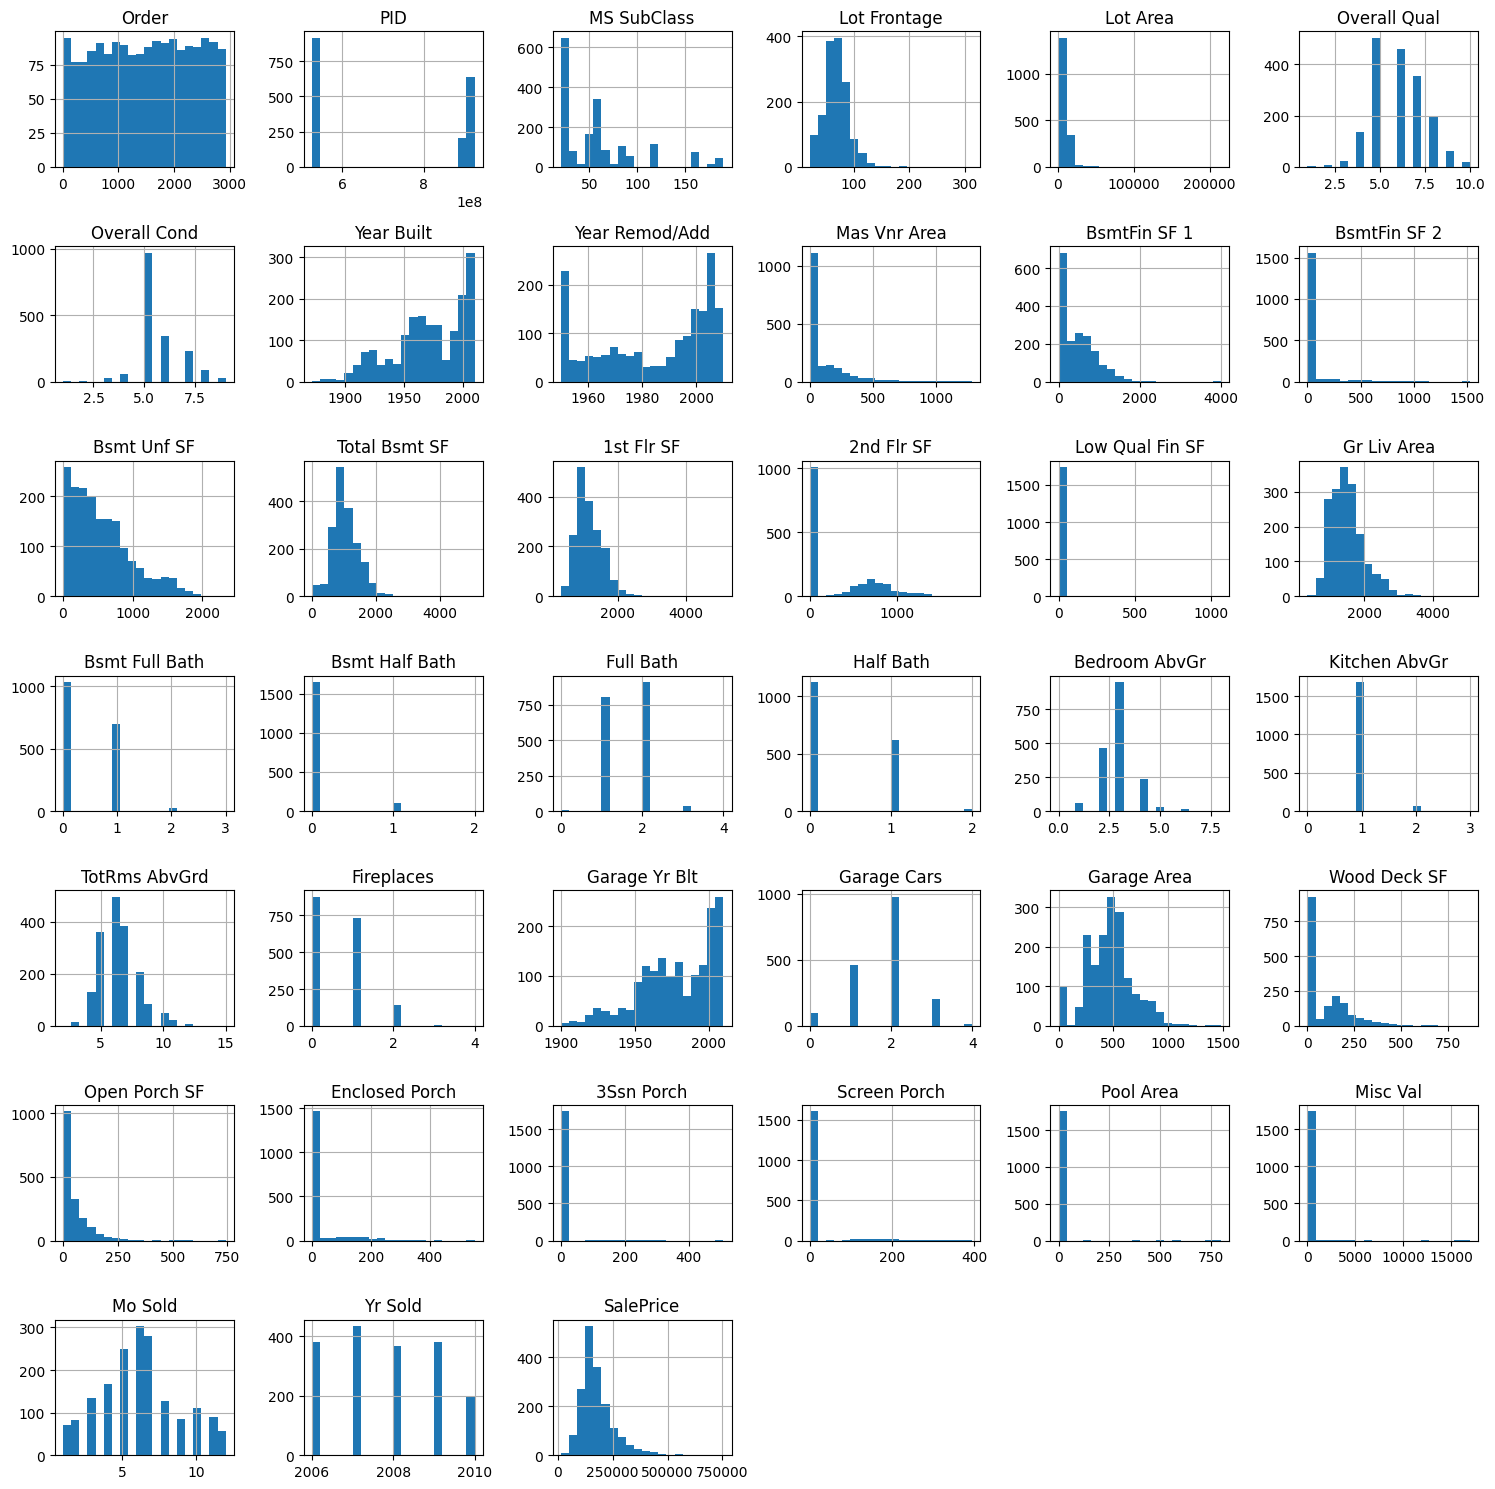

In [56]:
plt.figure(figsize=(15,15))
train_df[num.columns].hist(bins=20,figsize=(15,15))
plt.title("Numerical data distribution in details ")
plt.tight_layout()
plt.show()


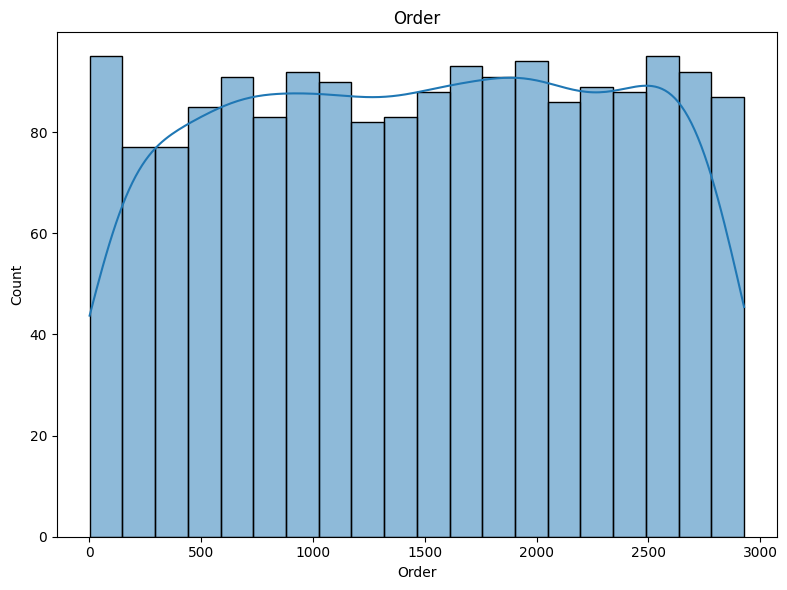

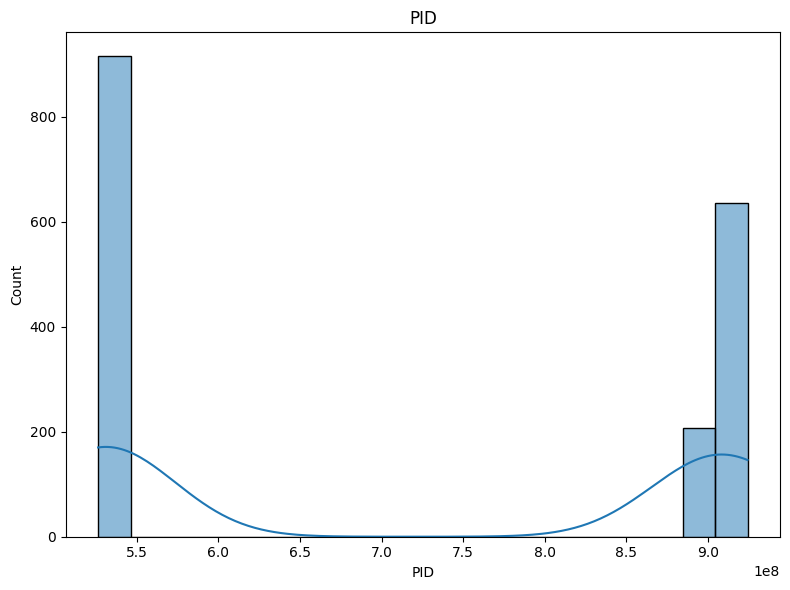

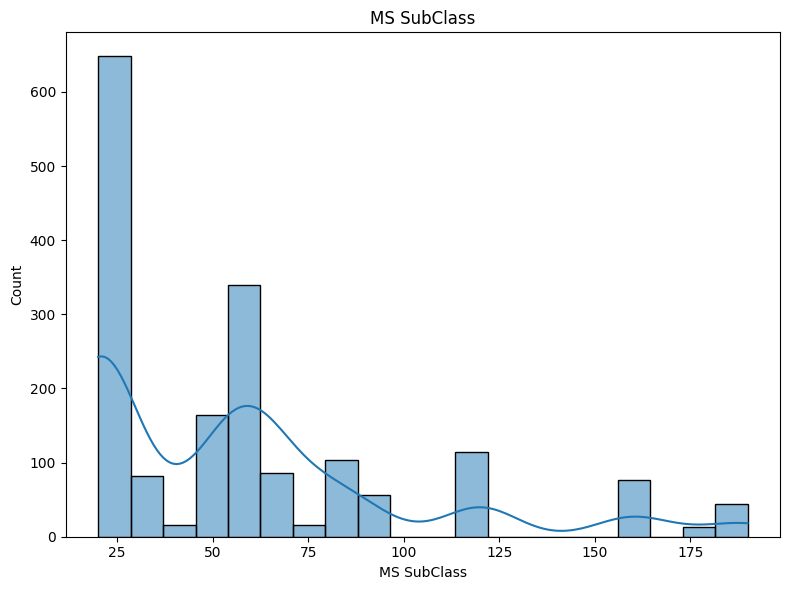

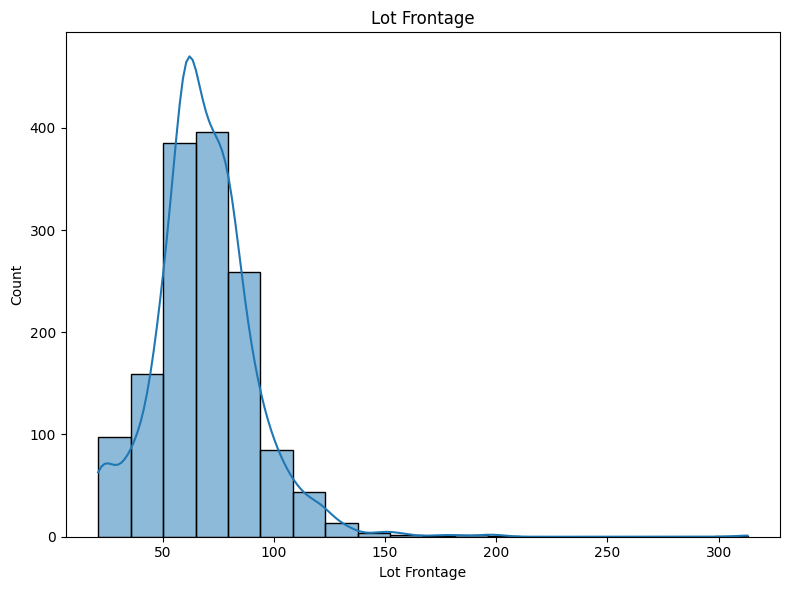

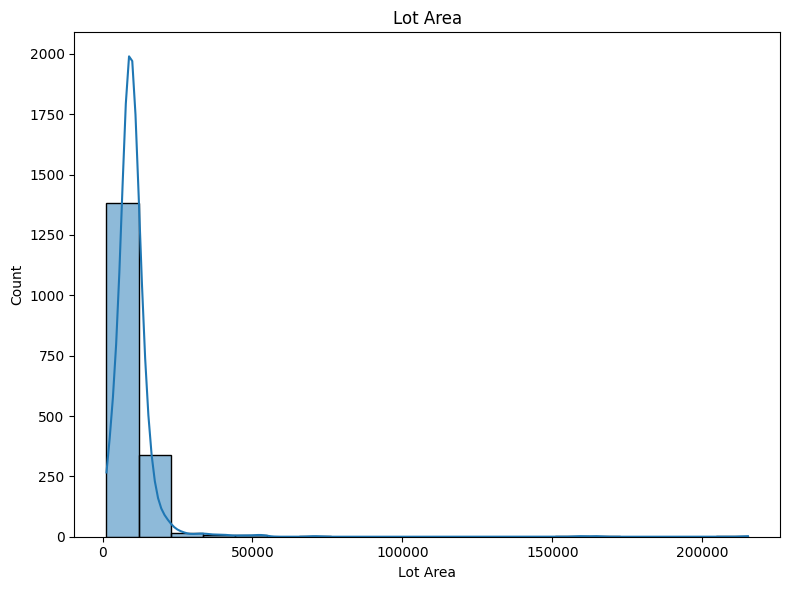

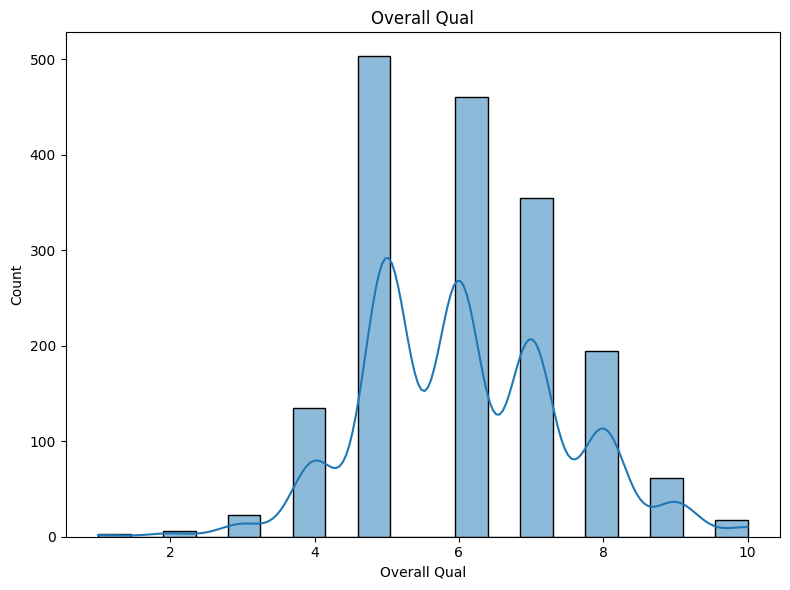

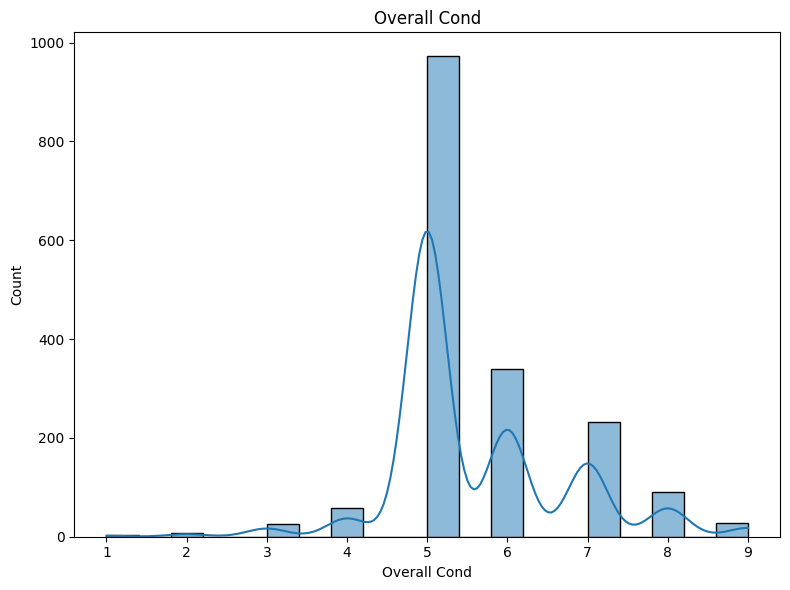

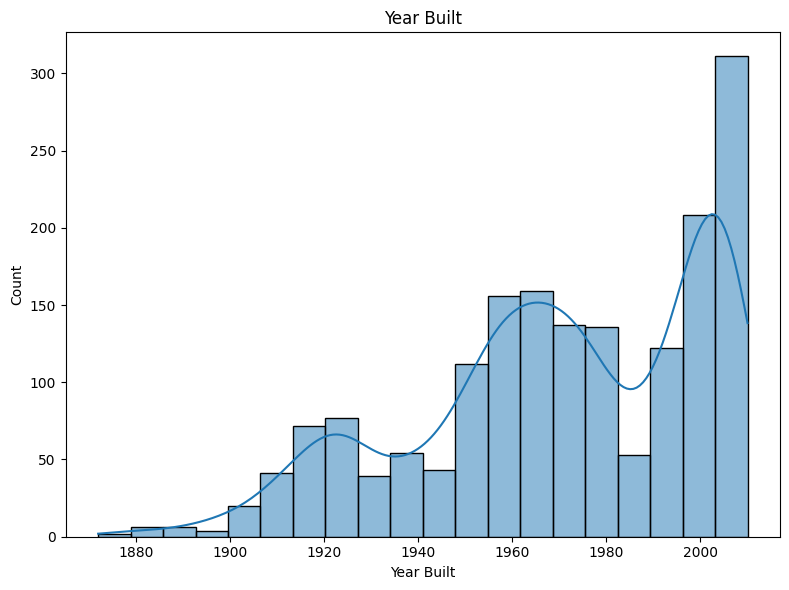

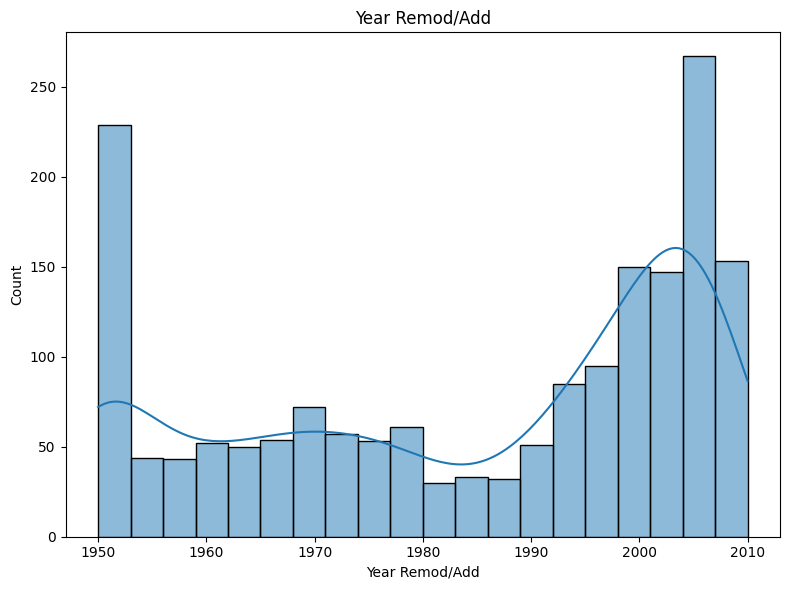

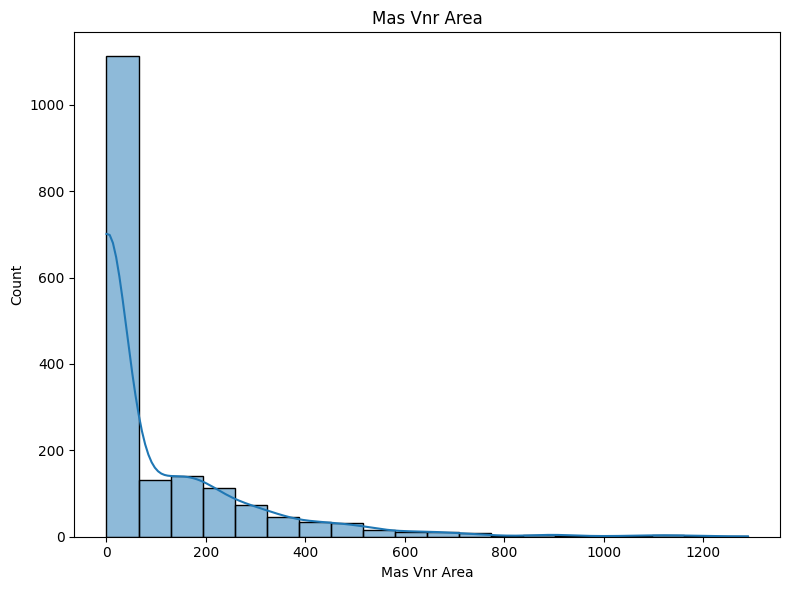

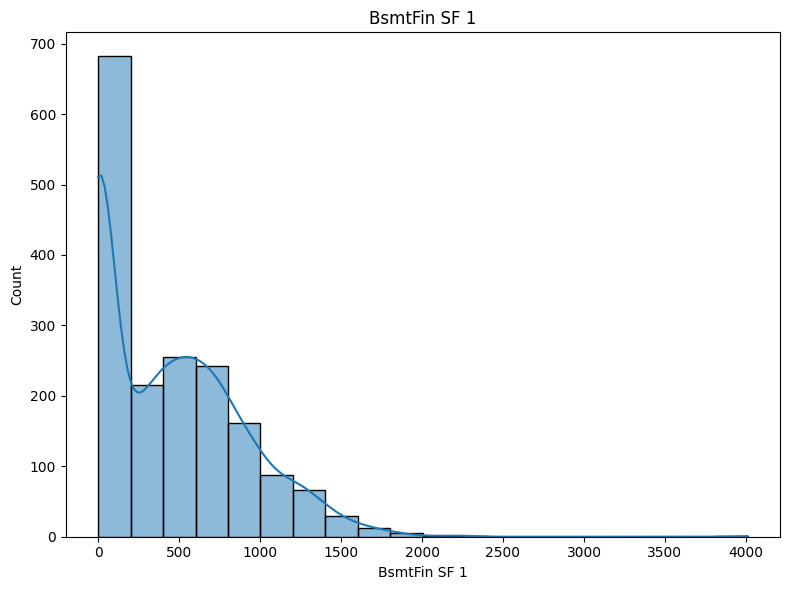

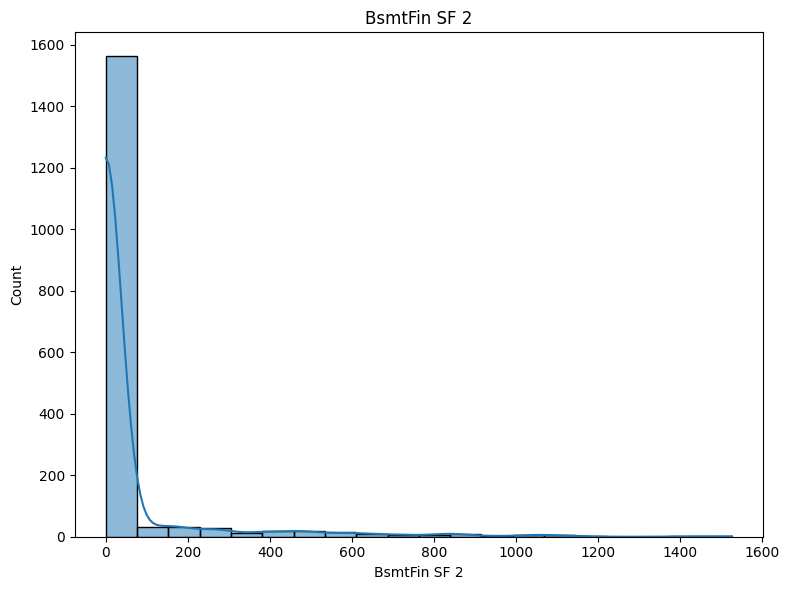

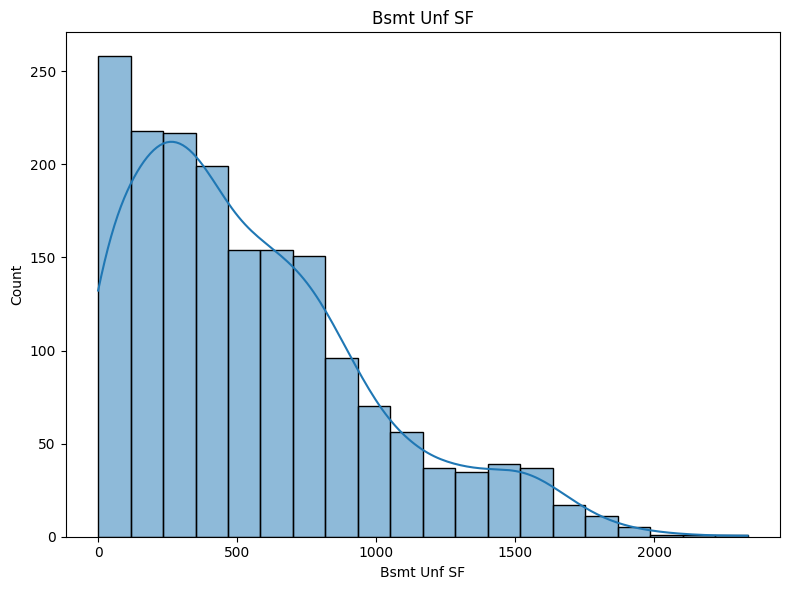

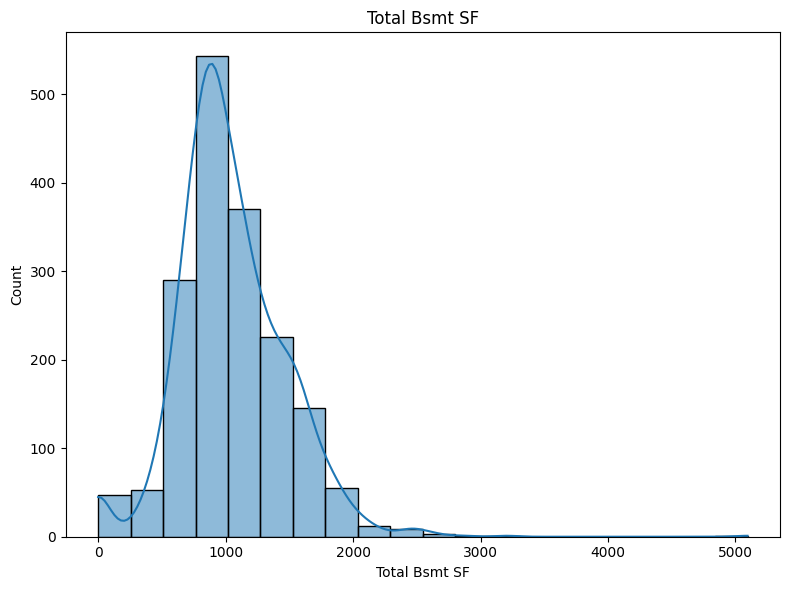

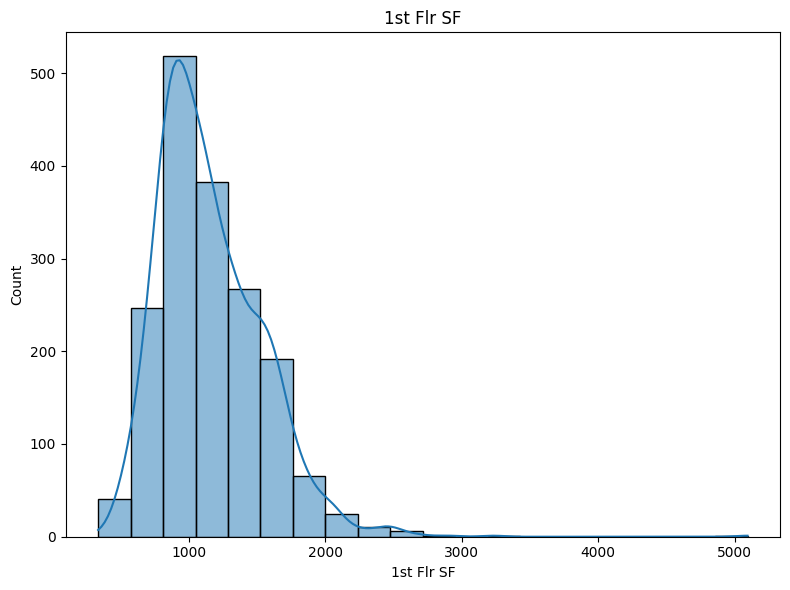

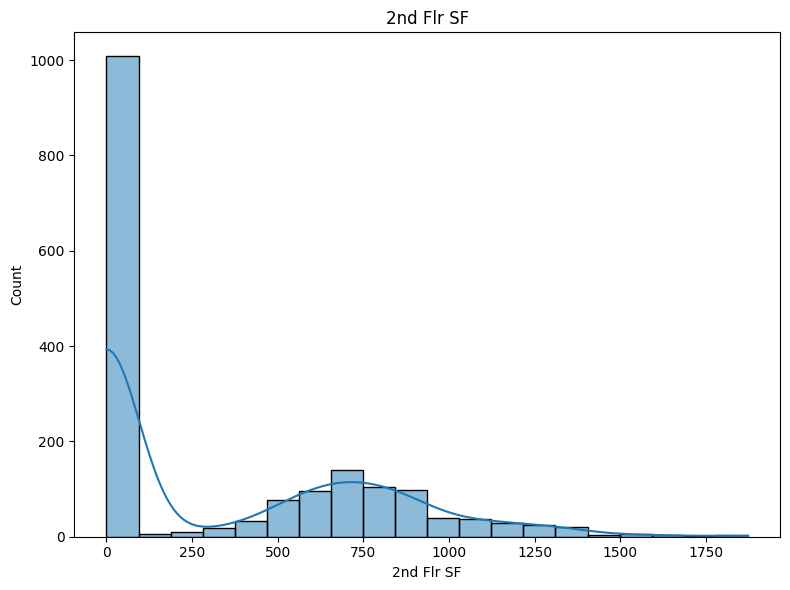

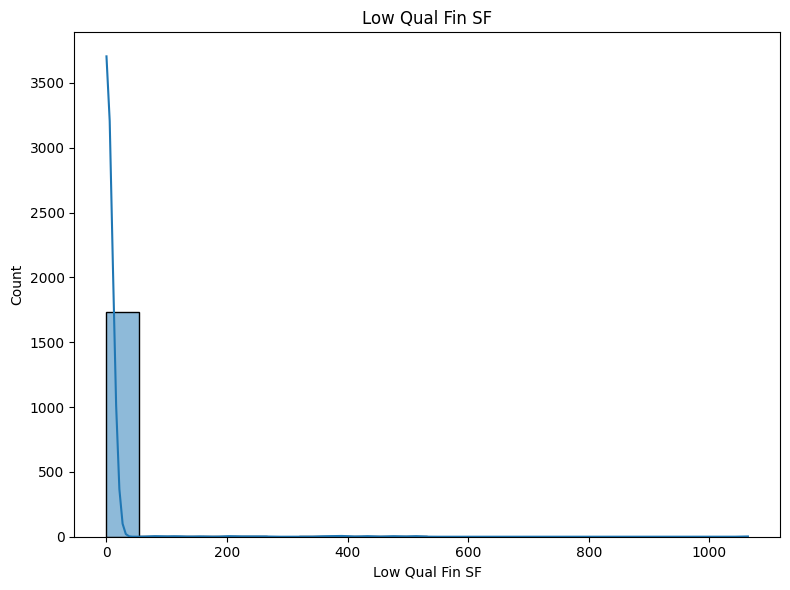

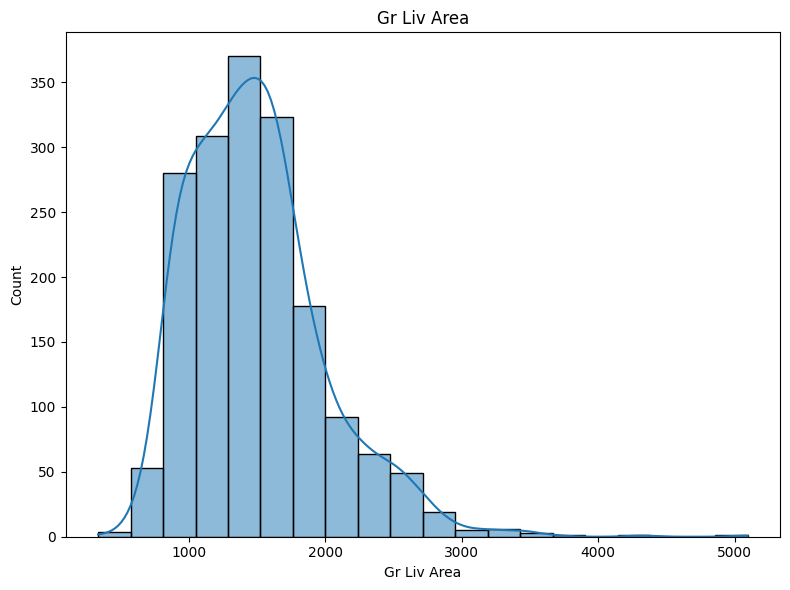

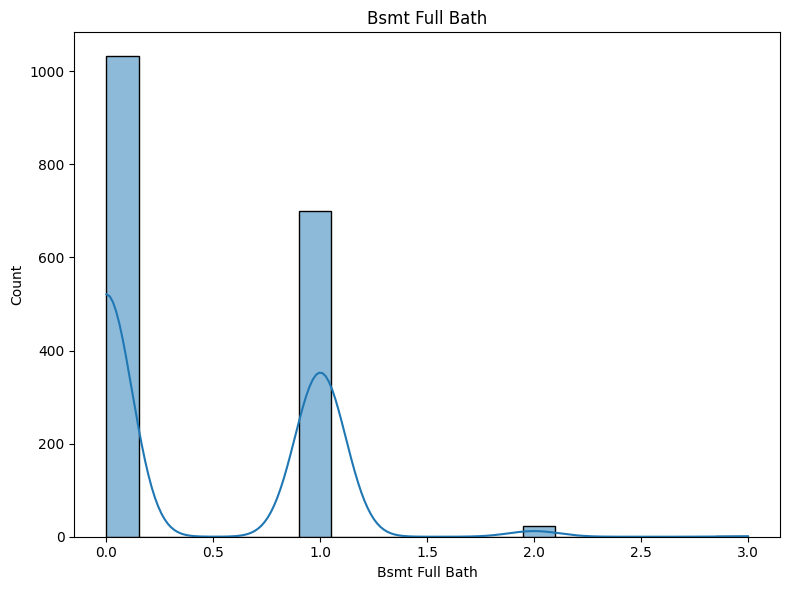

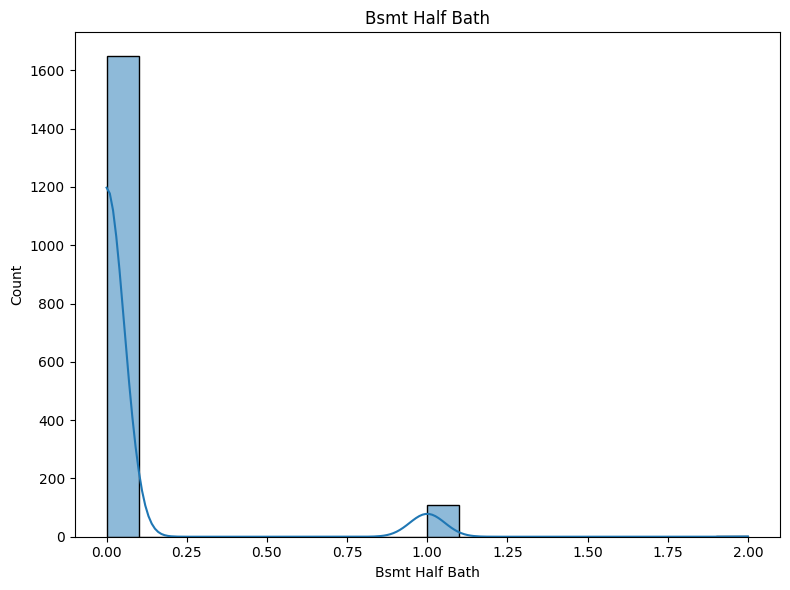

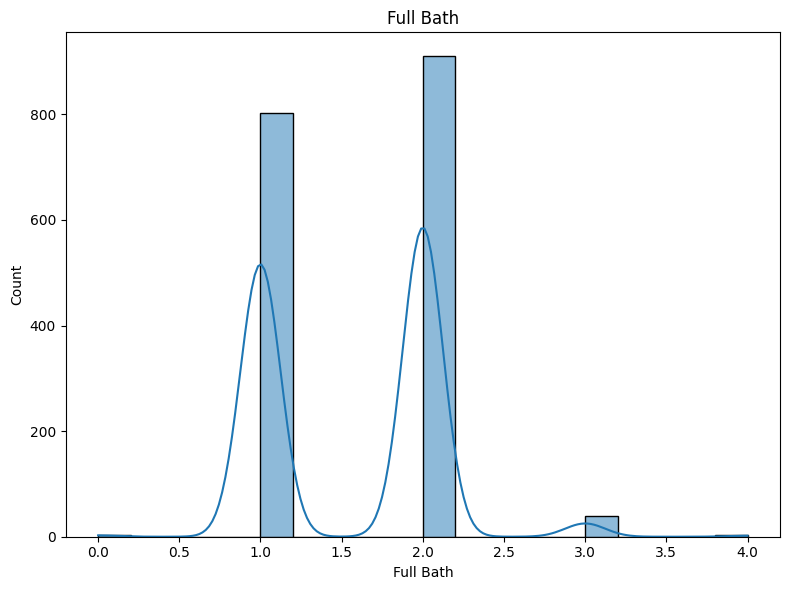

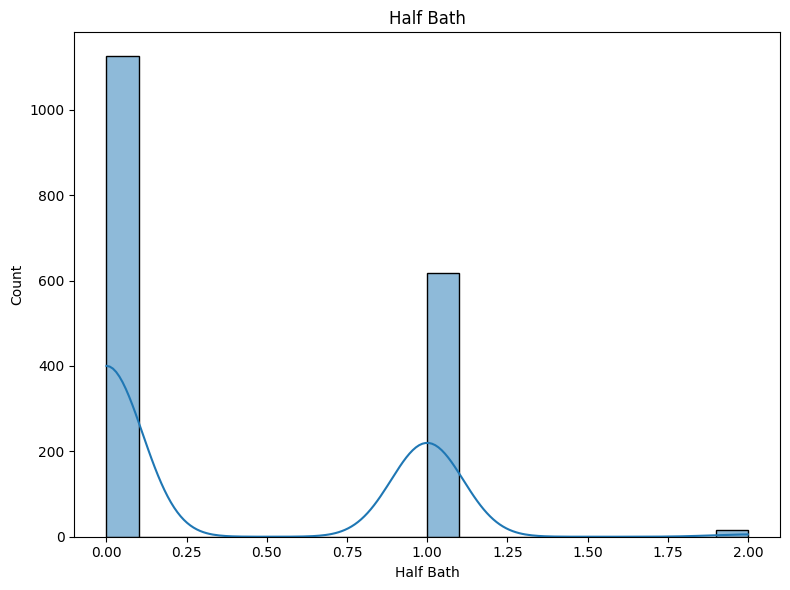

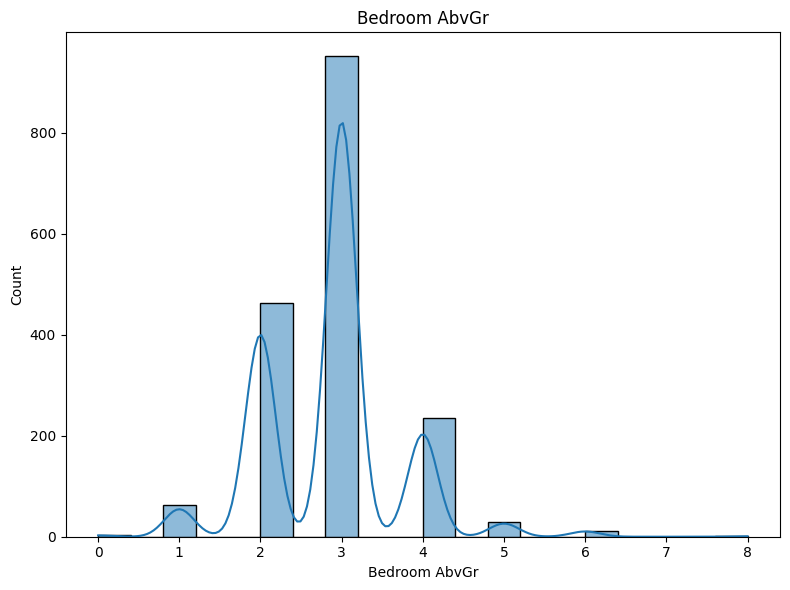

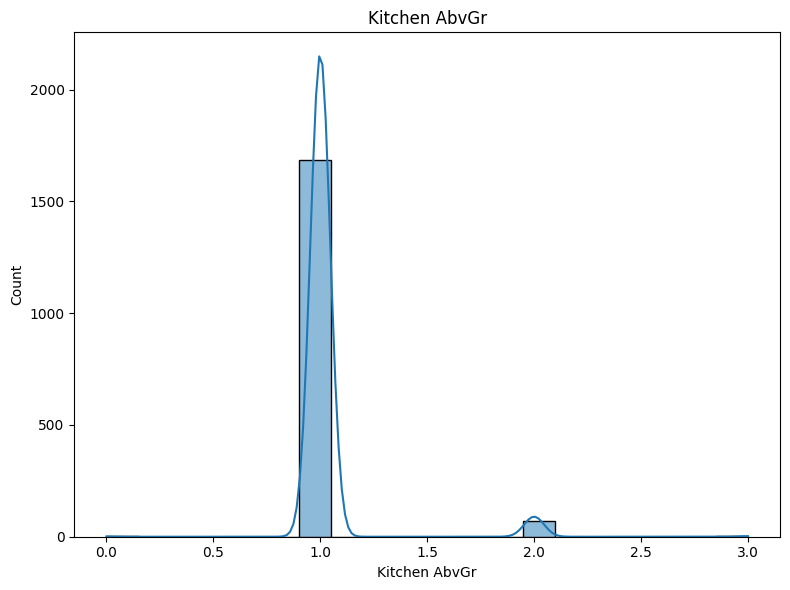

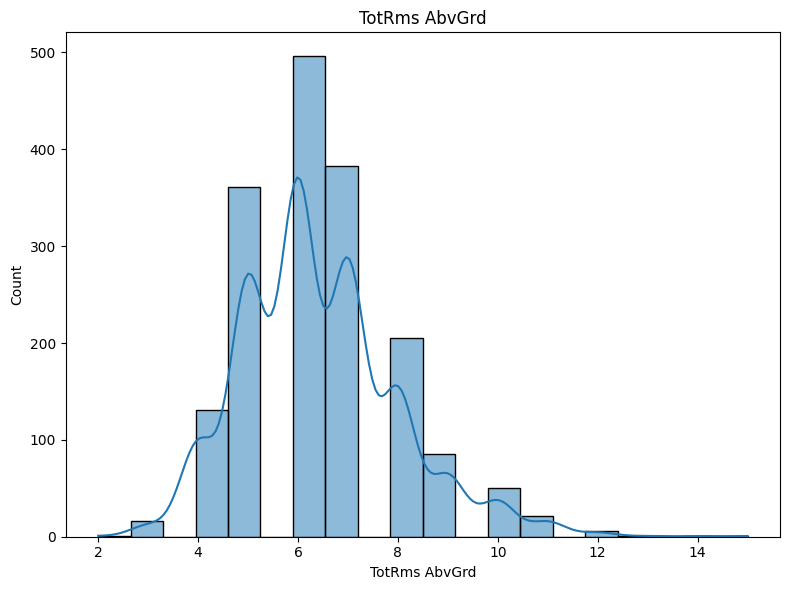

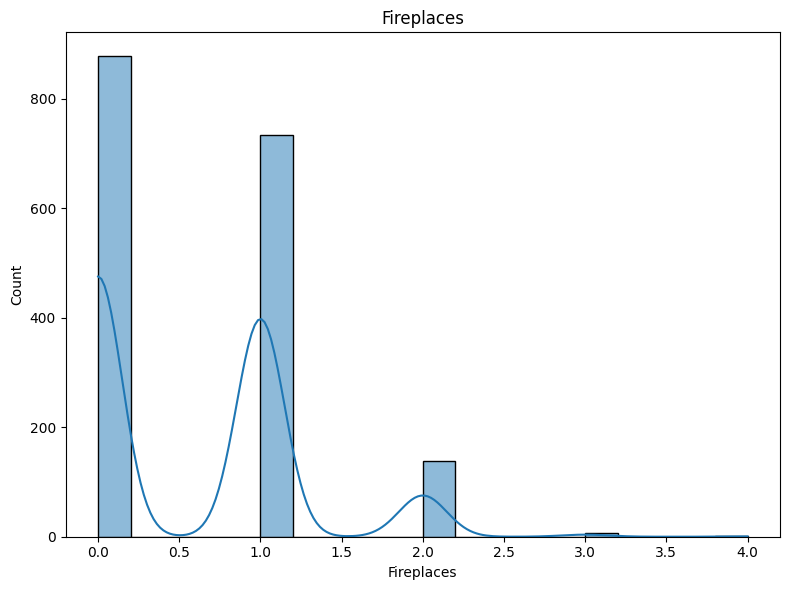

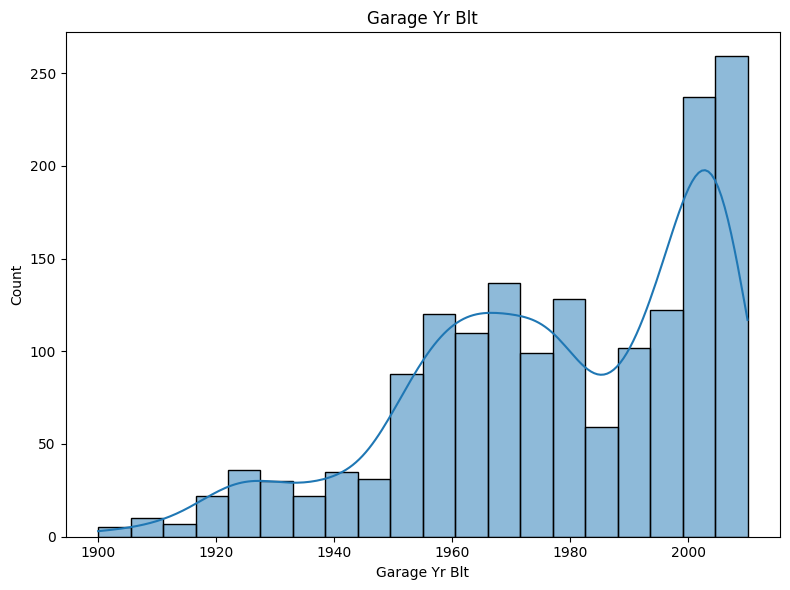

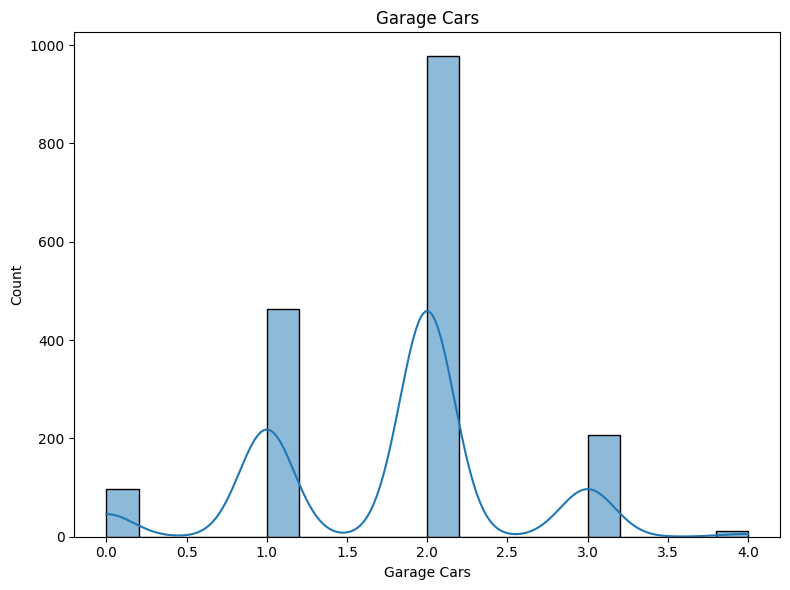

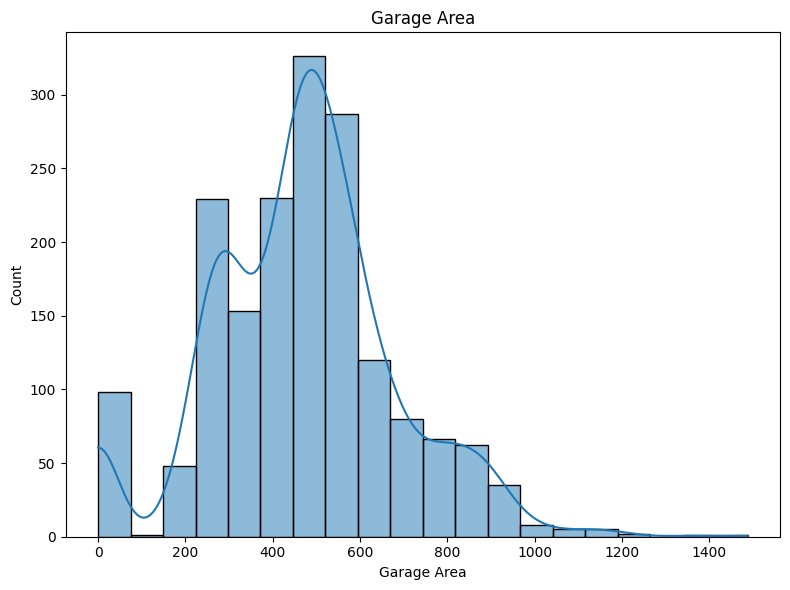

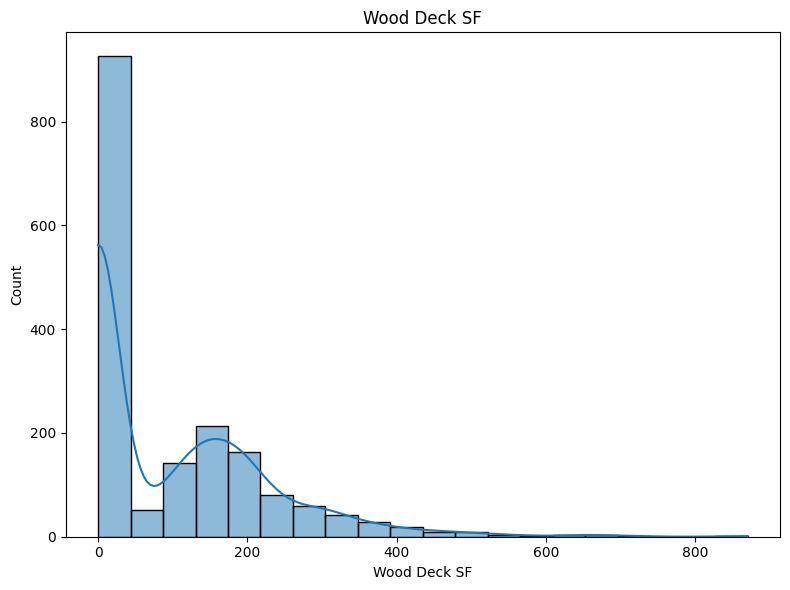

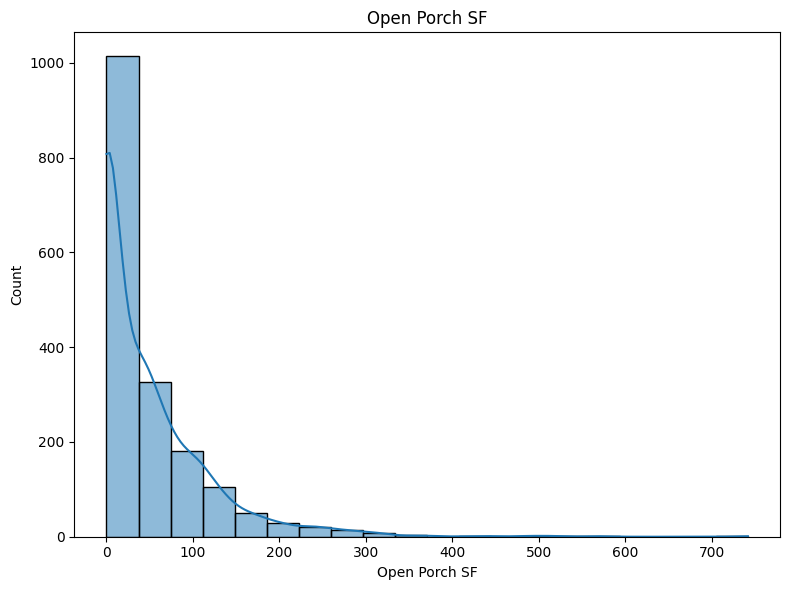

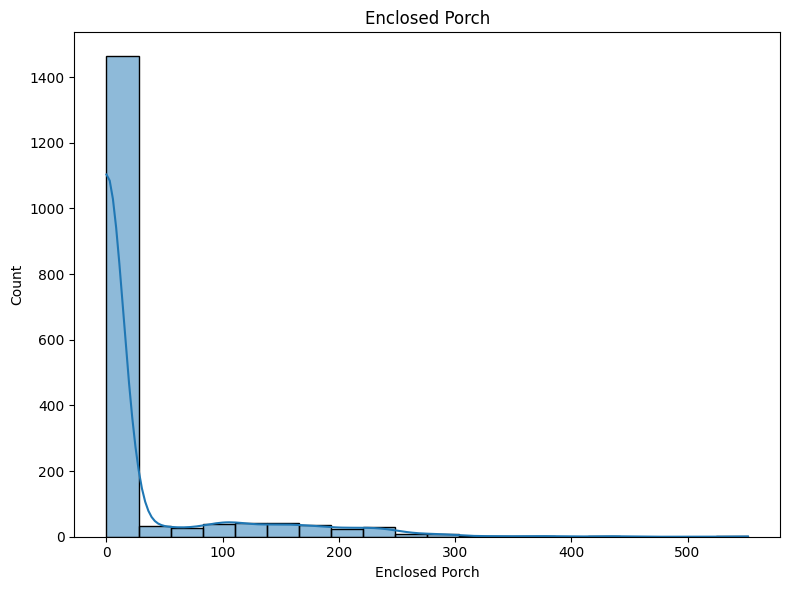

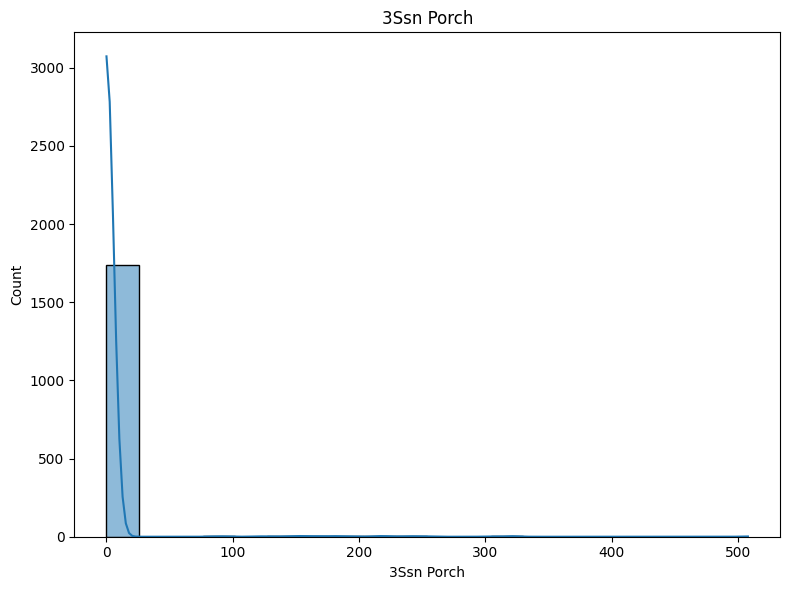

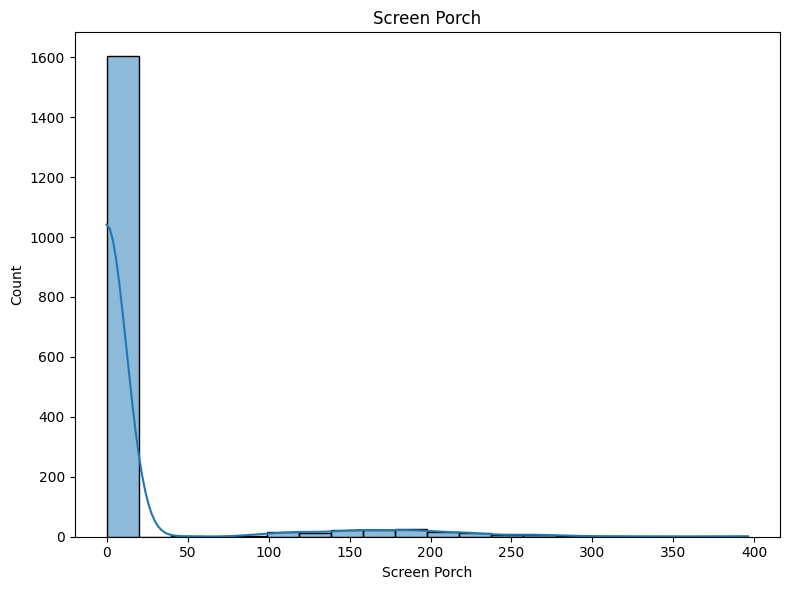

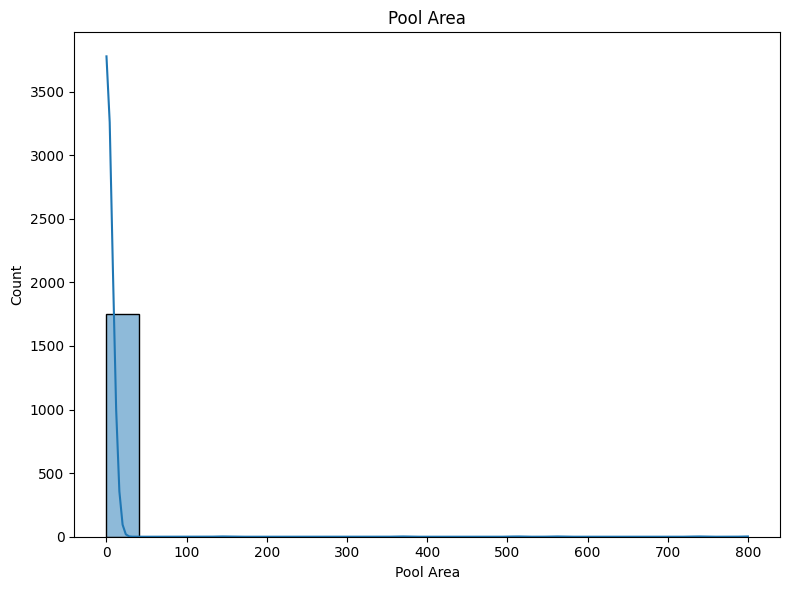

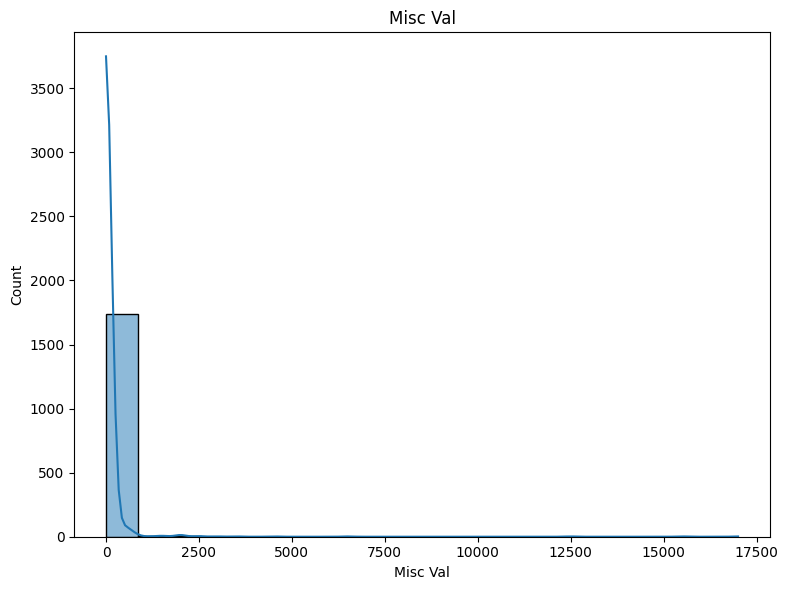

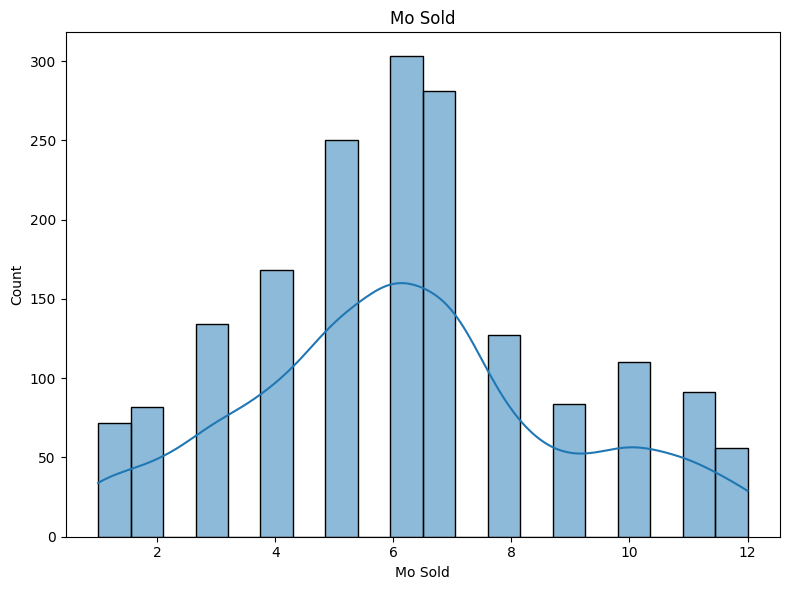

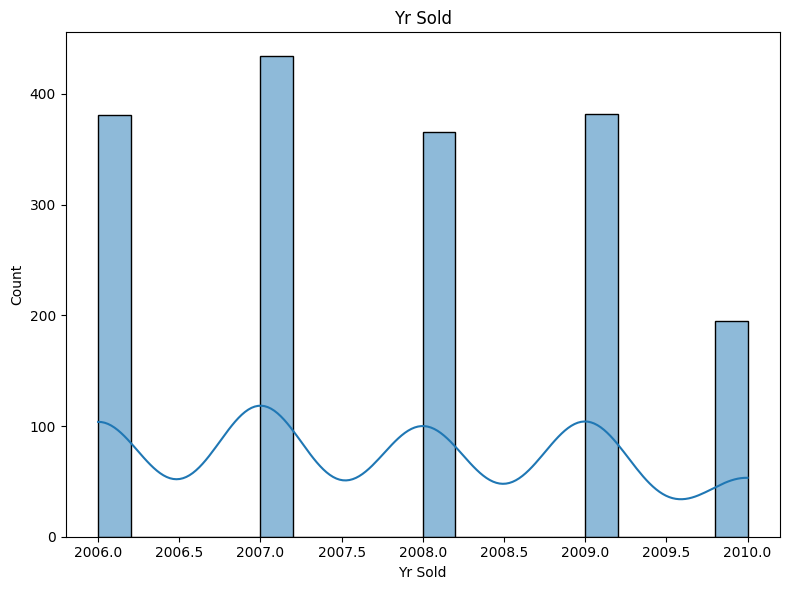

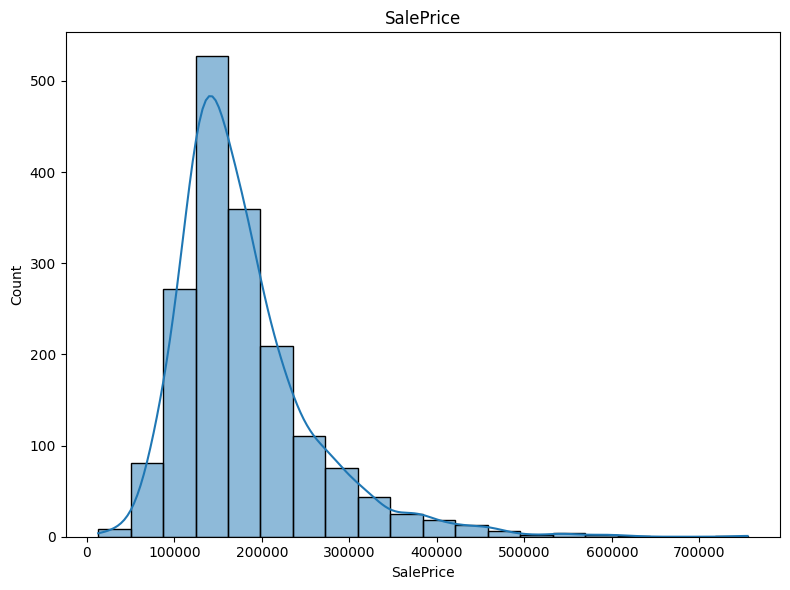

In [57]:
# see all the data kde to decide the missing value handeling terms
for col in num.columns:
  plt.figure(figsize=(8,6))
  sns.histplot(train_df[col],kde=True,bins=20)
  plt.title(f"{col}")
  plt.tight_layout()
  plt.show()

এখন দেখব আমাদের data-তে কোন outlier আছে কিনা।

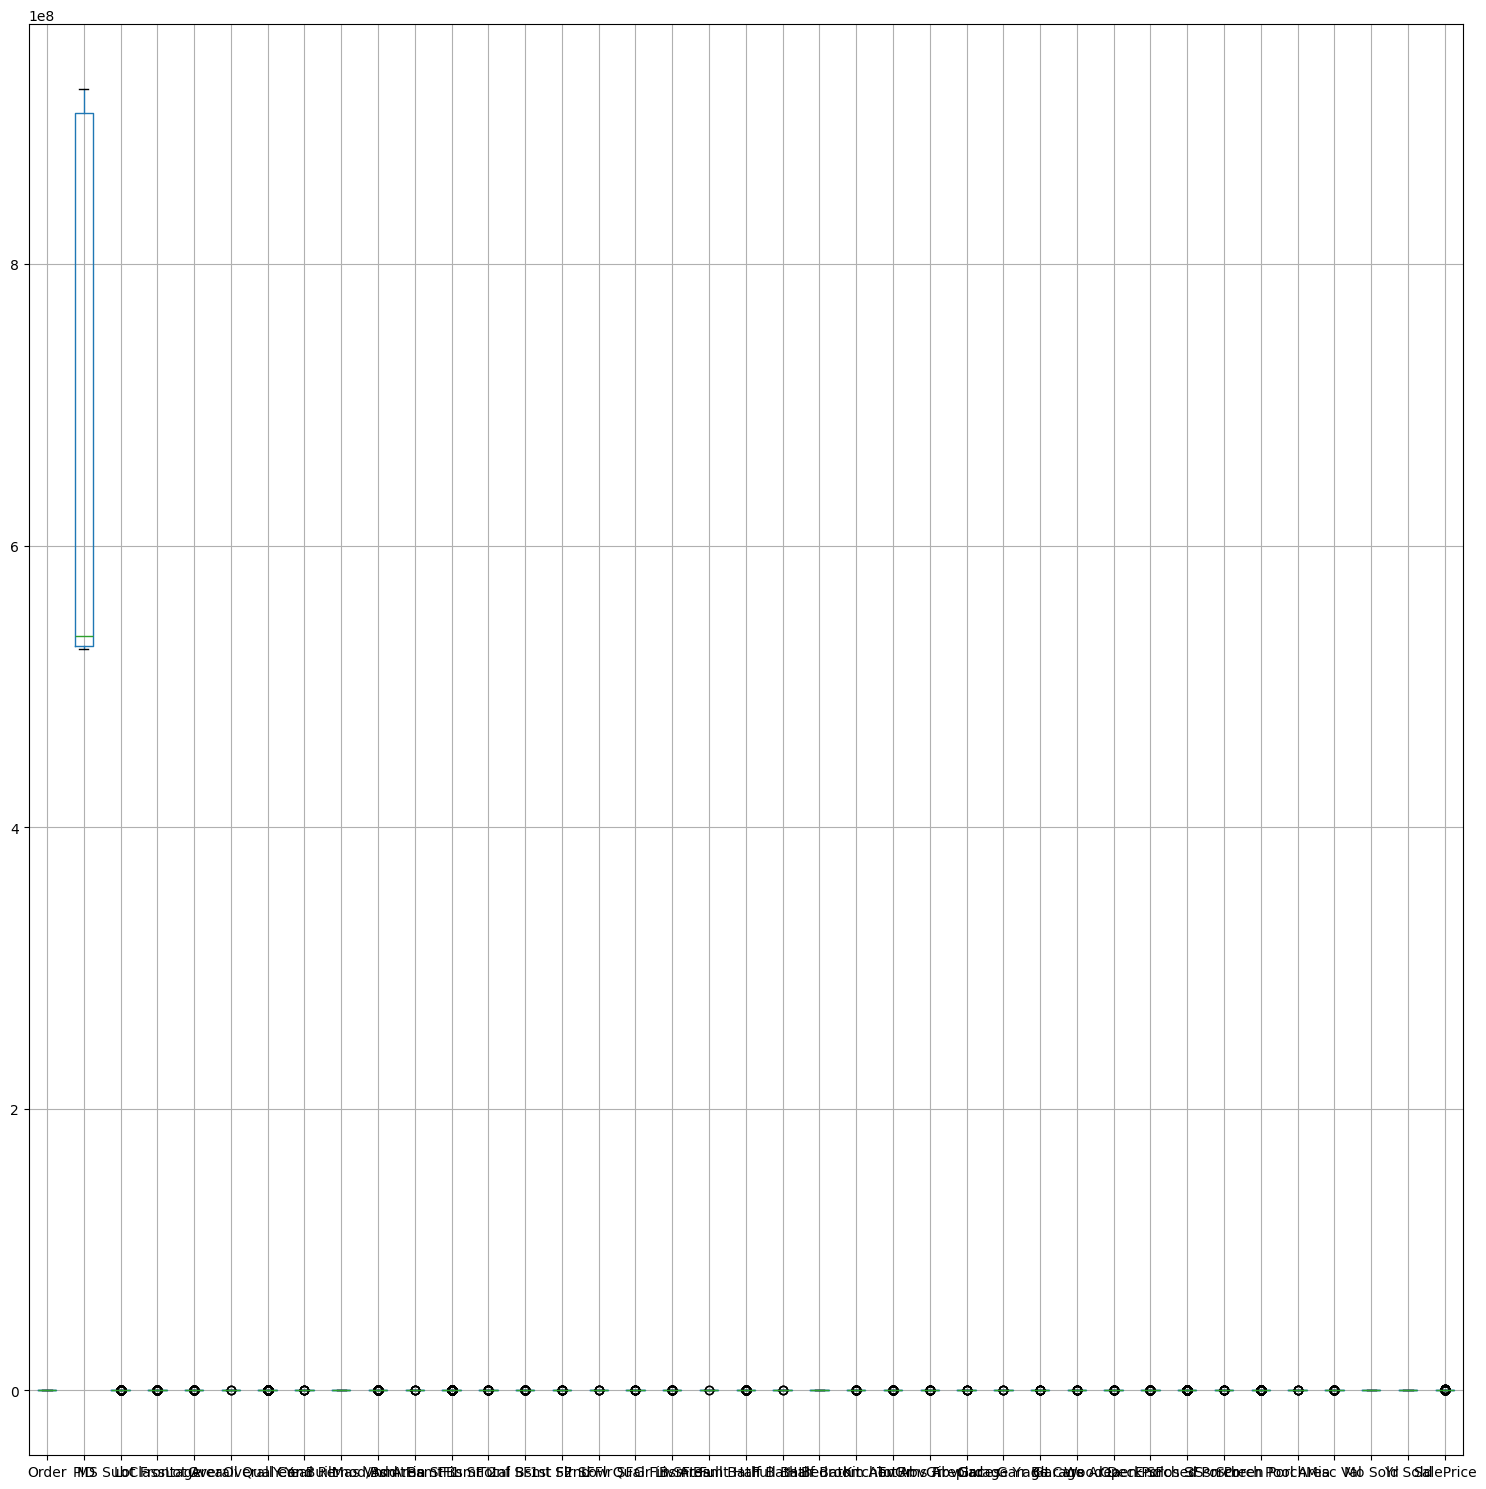

In [58]:
plt.figure(figsize=(15,15))
train_df[num.columns].boxplot()
plt.tight_layout()
plt.show()

Outlier handle করবো function এর মাধ্যমে।

In [59]:
def handle_outlier(df, col):

    df = df.copy()

    # Calculate Q1 and Q3
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = q3 - q1

    # Calculate lower and upper bounds
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    # See number of outliers
    outlier = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Number of outliers in {col}: {len(outlier)}")

    # Handle outliers using clipping
    df[col] = df[col].clip(lower=lower, upper=upper)

    return df

In [60]:
num


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,1323,902405070,70,60.0,10800,7,7,1890,1999,0.0,...,0,299,0,0,0,0,0,12,2008,184000
1,2476,531376030,60,65.0,7800,7,5,2005,2005,172.0,...,144,101,0,0,0,0,0,4,2006,184000
2,2091,906201022,20,114.0,10357,7,5,1990,1991,0.0,...,0,244,0,0,0,0,0,5,2007,179900
3,2734,905403050,50,62.0,6488,5,5,1942,1950,0.0,...,264,0,0,0,0,0,0,3,2006,128000
4,2882,911175440,190,50.0,9000,5,6,1951,1951,0.0,...,0,0,0,0,0,0,0,10,2006,115000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1753,1639,527226040,190,195.0,41600,5,5,1969,1990,0.0,...,144,0,0,0,0,0,0,11,2007,155000
1754,1096,528290090,60,NaN,7750,7,5,2002,2002,NaN,...,100,35,0,0,0,0,0,4,2008,176000
1755,1131,528490080,60,64.0,8791,6,5,2003,2003,0.0,...,216,56,0,0,0,0,0,5,2008,207500
1756,1295,902109160,50,81.0,7308,5,5,1920,1950,0.0,...,0,0,236,0,0,0,0,6,2008,122250


In [61]:
train_df = handle_outlier(train_df, 'Lot Frontage')
train_df = handle_outlier(train_df, 'Lot Area')
train_df = handle_outlier(train_df, 'Wood Deck SF')

Number of outliers in Lot Frontage: 105
Number of outliers in Lot Area: 81
Number of outliers in Wood Deck SF: 39


Separate X and Y.

In [62]:
x=train_df.drop(columns=['SalePrice'])
y=train_df['SalePrice']

In [63]:
y

,SalePrice
0,184000
1,184000
2,179900
3,128000
4,115000
...,...
1753,155000
1754,176000
1755,207500
1756,122250


In [64]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

Separate numerical and categorical columns.

In [65]:
numerical = x.select_dtypes(include=['int64','float64'])
categorical = x.select_dtypes(include=['object'])

#Create overall pipeline code.

In [66]:
num_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_trans =Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy='most_frequent')),
        ("onehot",OneHotEncoder(handle_unknown='ignore'))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ('num',num_trans,numerical.columns),
        ('cat',cat_trans,categorical.columns)

    ]
)

#Base model identify in details

In [67]:
# base model identify
lr=LinearRegression()
Elas=ElasticNet(alpha=0.1)
Sgd=SGDRegressor(loss='squared_error',max_iter=1000,alpha=0.001,random_state=42,eta0=0.01)
svr=SVR(max_iter=100,gamma=0.1,kernel='rbf',C=0.6,degree=3)
Rg=RandomForestRegressor(n_estimators=100,criterion='squared_error',min_samples_leaf=2,min_samples_split=3,max_features='sqrt',random_state=42)
Gb=GradientBoostingRegressor(n_estimators=100,loss='absolute_error',subsample=1,min_samples_leaf=3,max_features='sqrt',random_state=42)
Ada=AdaBoostRegressor(n_estimators=156,loss='linear',random_state=42)
Dtr=DecisionTreeRegressor(max_depth=3,min_samples_leaf=3,min_samples_split=3,random_state=42,criterion='absolute_error')
Knr=KNeighborsRegressor(n_neighbors=17,weights='distance',metric='minkowski')
XG=XGBRegressor(n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1)

In [69]:
stacking=StackingRegressor(
    estimators=[
         ('lr',lr),
         ('elas',Elas),
         ('Sgd',Sgd),
         ("svr",svr),
         ('Rg',Rg),
         ("GB",Gb),
         ("Ada",Ada),
         ("Dtr",Dtr),
         ('Knr',Knr),
         ('XG',XG)

    ],
   final_estimator=Ridge()
)


voting=VotingRegressor(
    estimators=[
         ('lr',lr),
         ('elas',Elas),
         ('Sgd',Sgd),
         ("svr",svr),
         ('Rg',Rg),
         ("GB",Gb),
         ("Ada",Ada),
         ("Dtr",Dtr),
         ('Knr',Knr)

    ]

)

In [70]:
model_to_train={
    'Logistic Regression' : lr,
    'Elas':Elas,
    "SGDRegressor":Sgd,
    "SVR":svr,
    "RandomForestRegressor":Rg,
    "GradientBoostingRegressor":Gb,
    "AdaBoostRegressor":Ada,
    'DecisionTreeRegressor':Dtr,
    "KNeighborsRegressor":Knr,
    "XGBRegressor":XG,
    "StackingRegressor":stacking,
    "VotingRegressor":voting


}

In [74]:
from sklearn.metrics import accuracy_score,r2_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [73]:
# Trainning pipe line
result=[]
for model_name,model in model_to_train.items():
    pipe=Pipeline(
        [("preprocessor",preprocessor),
        ("model",model)
        ]
    )
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    accuracy=r2_score(y_test,y_pred)
    result.append(
        {
            "model":model,
            'accuracy':accuracy
        }
    )

In [75]:
res=pd.DataFrame(result).sort_values(by='accuracy',ascending=False)
res

,model,accuracy
10,"StackingRegressor(estimators=[('lr', LinearReg...",0.928128
9,"XGBRegressor(base_score=None, booster=None, ca...",0.927480
1,ElasticNet(alpha=0.1),0.906325
2,"SGDRegressor(alpha=0.001, random_state=42)",0.902186
0,LinearRegression(),0.893736
5,([DecisionTreeRegressor(criterion='friedman_ms...,0.874072
4,"(DecisionTreeRegressor(max_features='sqrt', mi...",0.867460
11,"VotingRegressor(estimators=[('lr', LinearRegre...",0.850472
8,"KNeighborsRegressor(n_neighbors=17, weights='d...",0.823058
6,"(DecisionTreeRegressor(max_depth=3, random_sta...",0.805974


param_grid = {
    'final_estimator__alpha': [0.01, 0.1, 1, 10, 100],
    'passthrough': [True, False]
}
স্টাকিংয়ে ভালো পারফরম্যান্স করলে মূলত রিজের এই দুইটা প্যারামিটার দিয়ে ক্রস ভ্যালিডেশন করা হয় এবং গ্রিড সার্চ ইভি করা হয়।

In [76]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np
import pandas as pd

# Training Pipeline
result = []

for model_name, model in model_to_train.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x_train, y_train)

    y_pred = pipe.predict(x_test)

    # Regression Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    result.append({
        "Model": model_name,
        "R2 Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

# Convert to DataFrame
res = pd.DataFrame(result).sort_values(
    by="R2 Score",
    ascending=False
)

res

,Model,R2 Score,MAE,MSE,RMSE
10,StackingRegressor,0.928128,13240.888340,4.456938e+08,21111.462498
9,XGBRegressor,0.927480,13548.894531,4.497144e+08,21206.470711
1,Elas,0.906325,15620.113450,5.809023e+08,24101.915592
2,SGDRegressor,0.902186,15300.002993,6.065683e+08,24628.607822
0,Logistic Regression,0.893736,16090.651632,6.589669e+08,25670.351510
5,GradientBoostingRegressor,0.874072,16844.318930,7.809134e+08,27944.828533
4,RandomForestRegressor,0.867460,17852.680947,8.219135e+08,28669.034052
11,VotingRegressor,0.850472,19122.153027,9.272608e+08,30450.958081
8,KNeighborsRegressor,0.823058,20567.592855,1.097263e+09,33124.953709
6,AdaBoostRegressor,0.805974,25751.949383,1.203207e+09,34687.278564


এখানে যেই মডেলটা সবচেয়ে ভালো করছে, তার ক্রস ভ্যালিডেশন করব।

In [77]:
xg_pipeline= Pipeline(
    [
        ('preprocessor',preprocessor),
        ('model',XG)
    ]
)

In [78]:
# Cross validation
cv_result=cross_val_score(xg_pipeline,x_train,y_train,cv=5,scoring='r2')

cv_acc=cv_result.mean()
cv_std=cv_result.std()

cv_acc,cv_std,cv_result

(np.float64(0.8959450721740723),
 np.float64(0.02987175950500175),
 array([0.90212345, 0.93046594, 0.84011346, 0.90330565, 0.90371686]))

fine tunning of xg boost

In [80]:
param_grid = {
    "model__n_estimators": [200, 500, 900, 1000, 1100],
    "model__learning_rate": [0.04, 0.1, 0.2, 0.3, 0.5],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 2, 3, 4, 5],
    "model__subsample": [0.4, 0.5, 0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.8, 1.0],
    "model__reg_alpha": [0.1, 0.2, 0.5],
    "model__reg_lambda": [1, 2, 4]
}

In [82]:
grid=GridSearchCV(
    estimator=xg_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1

)

এইখানে যদি স্কোরিং আর টু না হয়ে অন্য কিছু হতো, তাহলে এই কোডটি লিখতাম।
# R²
scoring="r2"

# MSE
scoring="neg_mean_squared_error"

# RMSE
scoring="neg_root_mean_squared_error"

# MAE
scoring="neg_mean_absolute_error"

In [ ]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 67500 candidates, totalling 337500 fits


In [ ]:
print(grid.best_params_)
print(grid.best_score_)

model = grid.best_estimator_

In [ ]:
preds=model.predict(test_df)
submission=pd.Dataframe(
    {
        'PID':test_ids,
        'SalePrice':preds
    }
)
submission.to_csv('submission.csv',index=False)

